# Seller Curves by Product (Improved Readability)

This notebook draws results by **product (car)** as subsections.

Layout:
- each car has 4 figures
- each figure is 3x3 (rows: buyer A/B/C, cols: 3 seller policies)

Plot rules:
- y-axis uses normal seller quote `S_t`
- each simulation trajectory uses a different color
- marker style encodes buyer jump:
  - hollow circle: `ΔB = B_t - B_{t-1} = 10`
  - filled circle: `ΔB = B_t - B_{t-1} = 1000`
- marker legend is inside each subplot
- `t=1` is excluded from marker detection


In [22]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import display, Markdown

plt.style.use('seaborn-v0_8-whitegrid')
RESULTS_DIR = Path('results')
files = sorted(RESULTS_DIR.glob('user_[ABC]_*.json'))
if not files:
    files = sorted(RESULTS_DIR.glob('*.json'))
print(f'Found {len(files)} files in {RESULTS_DIR.resolve()}')


Found 180 files in /Users/weiziyi/Desktop/Research/LLMNego_Plus/EXP/0425_fixed_buyer_strategic_seller_Ziyi/results


In [23]:
def normalize_car_name(car_obj):
    if isinstance(car_obj, str):
        return car_obj
    if isinstance(car_obj, dict):
        return car_obj.get('car_name') or car_obj.get('name') or str(car_obj)
    return str(car_obj)

def extract_dealer_cost(car_obj):
    if isinstance(car_obj, dict):
        x = car_obj.get('dealer_cost')
        return float(x) if x is not None else np.nan
    return np.nan

records = []
for fp in files:
    with fp.open('r', encoding='utf-8') as f:
        obj = json.load(f)

    for run_idx, run in enumerate(obj.get('runs', []), start=1):
        car_obj = run.get('car')
        records_run_base = {
            'file': fp.name,
            'run_idx': run_idx,
            'sim_id': f"{fp.name}|run{run_idx}",
            'buyer_scheme': run.get('buyer_scheme'),
            'policy': run.get('policy'),
            'car': normalize_car_name(car_obj),
        }

        bs = run.get('buyer_state')
        if isinstance(bs, dict) and bs.get("v") is not None:
            v = float(bs.get('v'))
        else:
            v = extract_dealer_cost(car_obj)

        for rd in run.get('rounds', []):
            t = rd.get('round')
            b = rd.get('buyer_price')
            s = rd.get('seller_price')
            if t is None or b is None or s is None:
                continue
            row = dict(records_run_base)
            row.update({
                't': int(t),
                'B_t': float(b),
                'S_t': float(s),
                'v': v,
            })
            records.append(row)

df = pd.DataFrame(records)
assert not df.empty, 'No valid round records found.'
df = df.sort_values(["sim_id", "t"]).reset_index(drop=True)

df['B_prev'] = df.groupby('sim_id')['B_t'].shift(1)
df['dB'] = df['B_t'] - df['B_prev']
df_mark = df[(df["t"] > 1) & df["B_prev"].notna()].copy()

tol = 1e-6
df_mark["is_db_10"] = np.isclose(df_mark["dB"], 10.0, atol=tol)
df_mark["is_db_1000"] = np.isclose(df_mark["dB"], 1000.0, atol=tol)

display(df_mark[["t", "dB", "B_t", "S_t", "v", "buyer_scheme", "policy", "car", "sim_id"]].head(12))
print("Rows for lines:", len(df), "| Rows for markers (t>1):", len(df_mark))


,t,dB,B_t,S_t,v,buyer_scheme,policy,car,sim_id
1,2,10.0,8874.21,28500.0,19000.0,A,chatterjee_aggressive_high_ask,2014 Mercedes-Benz S550,user_A_chatterjee_aggressive_high_ask_v1.json|...
2,3,0.0,8874.21,28500.0,19000.0,A,chatterjee_aggressive_high_ask,2014 Mercedes-Benz S550,user_A_chatterjee_aggressive_high_ask_v1.json|...
3,4,0.0,8874.21,28500.0,19000.0,A,chatterjee_aggressive_high_ask,2014 Mercedes-Benz S550,user_A_chatterjee_aggressive_high_ask_v1.json|...
4,5,1000.0,9874.21,28000.0,19000.0,A,chatterjee_aggressive_high_ask,2014 Mercedes-Benz S550,user_A_chatterjee_aggressive_high_ask_v1.json|...
5,6,10.0,9884.21,28000.0,19000.0,A,chatterjee_aggressive_high_ask,2014 Mercedes-Benz S550,user_A_chatterjee_aggressive_high_ask_v1.json|...
6,7,0.0,9884.21,28000.0,19000.0,A,chatterjee_aggressive_high_ask,2014 Mercedes-Benz S550,user_A_chatterjee_aggressive_high_ask_v1.json|...
7,8,0.0,9884.21,27900.0,19000.0,A,chatterjee_aggressive_high_ask,2014 Mercedes-Benz S550,user_A_chatterjee_aggressive_high_ask_v1.json|...
8,9,10.0,9894.21,27900.0,19000.0,A,chatterjee_aggressive_high_ask,2014 Mercedes-Benz S550,user_A_chatterjee_aggressive_high_ask_v1.json|...
9,10,0.0,9894.21,27900.0,19000.0,A,chatterjee_aggressive_high_ask,2014 Mercedes-Benz S550,user_A_chatterjee_aggressive_high_ask_v1.json|...
10,11,0.0,9894.21,27900.0,19000.0,A,chatterjee_aggressive_high_ask,2014 Mercedes-Benz S550,user_A_chatterjee_aggressive_high_ask_v1.json|...


Rows for lines: 50267 | Rows for markers (t>1): 48467


## Product: 2014 Mercedes-Benz S550

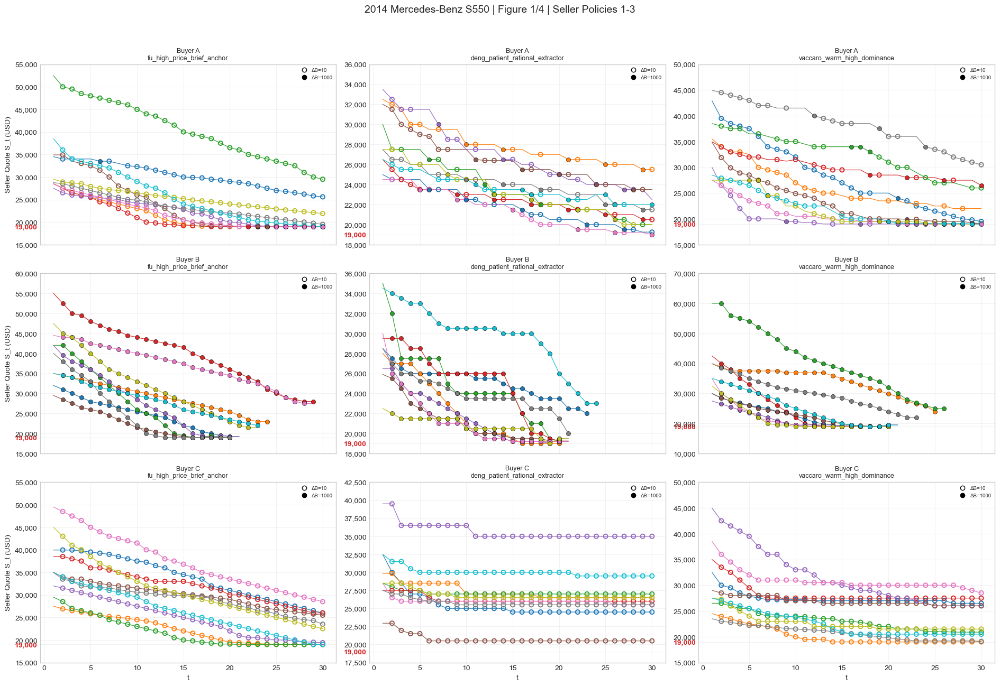

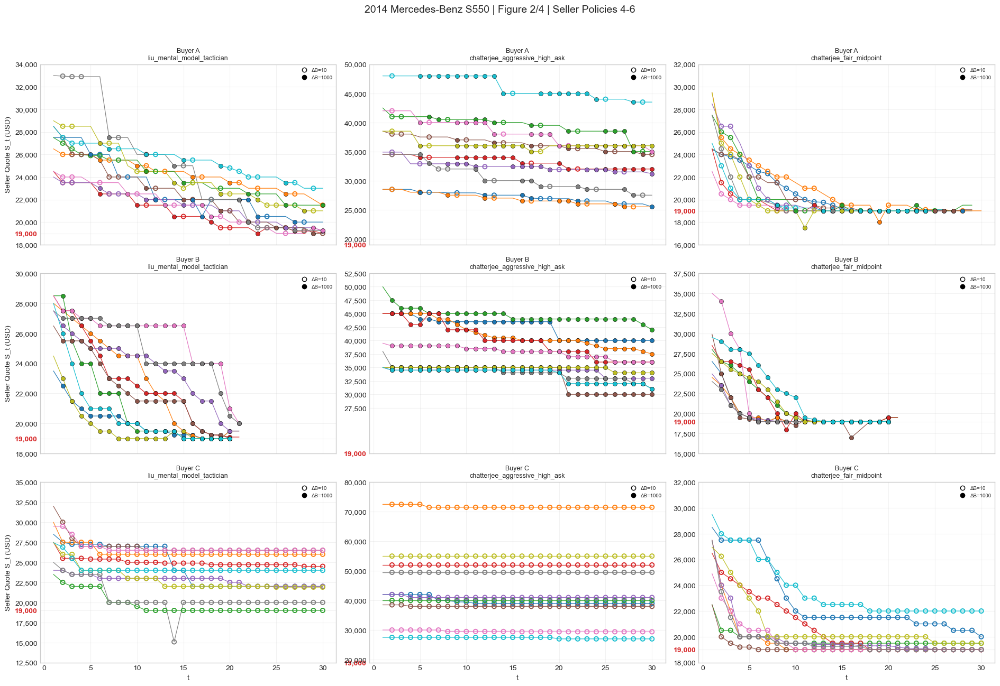

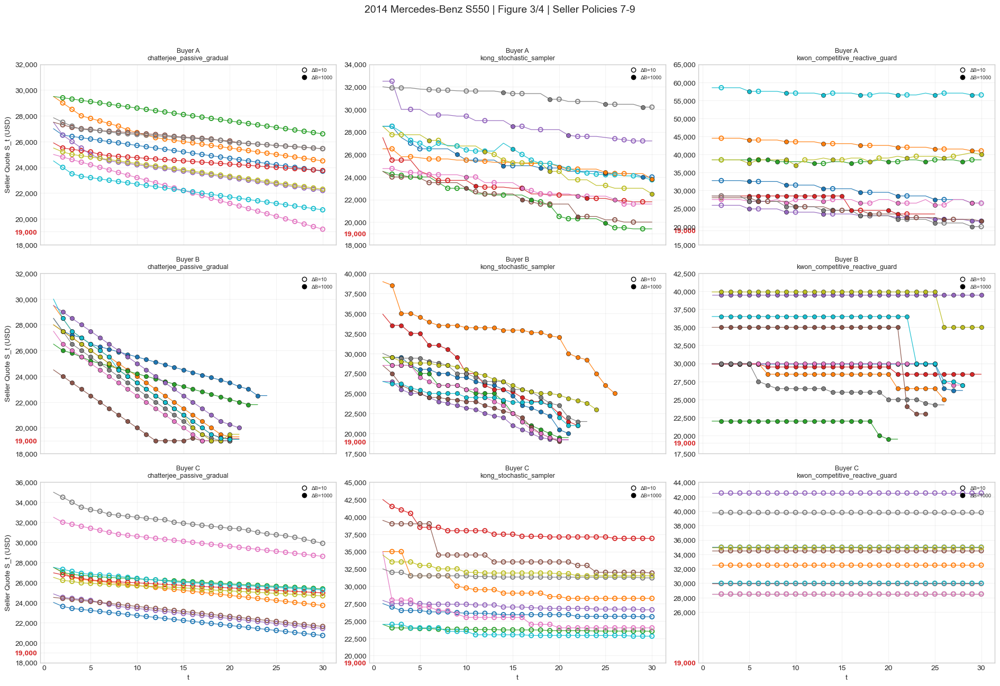

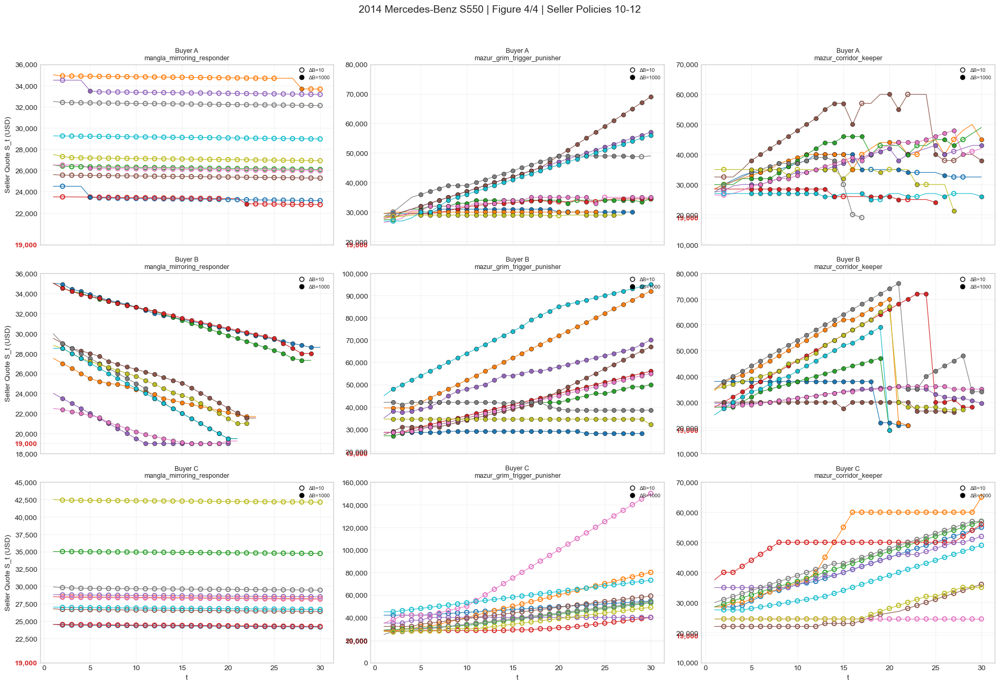

## Product: 2016 Cadillac CTS 3.6 Luxury

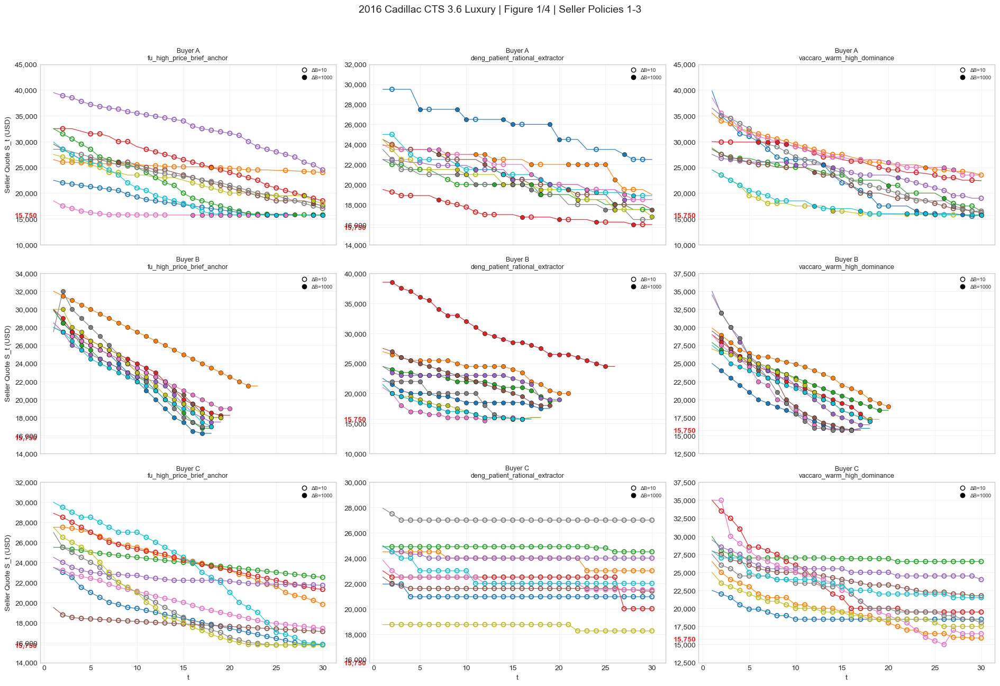

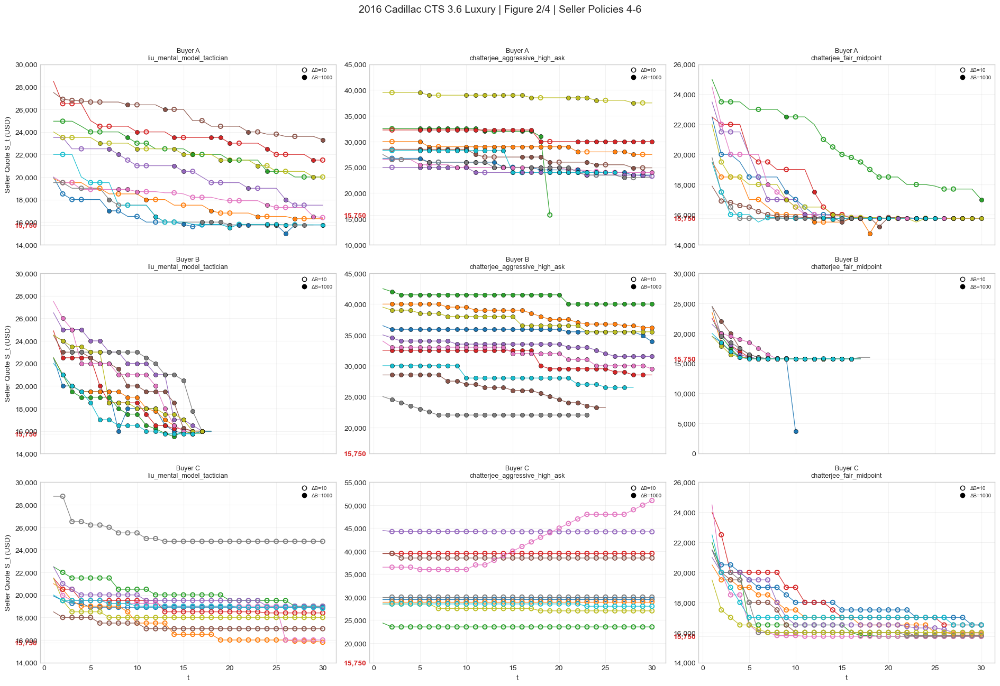

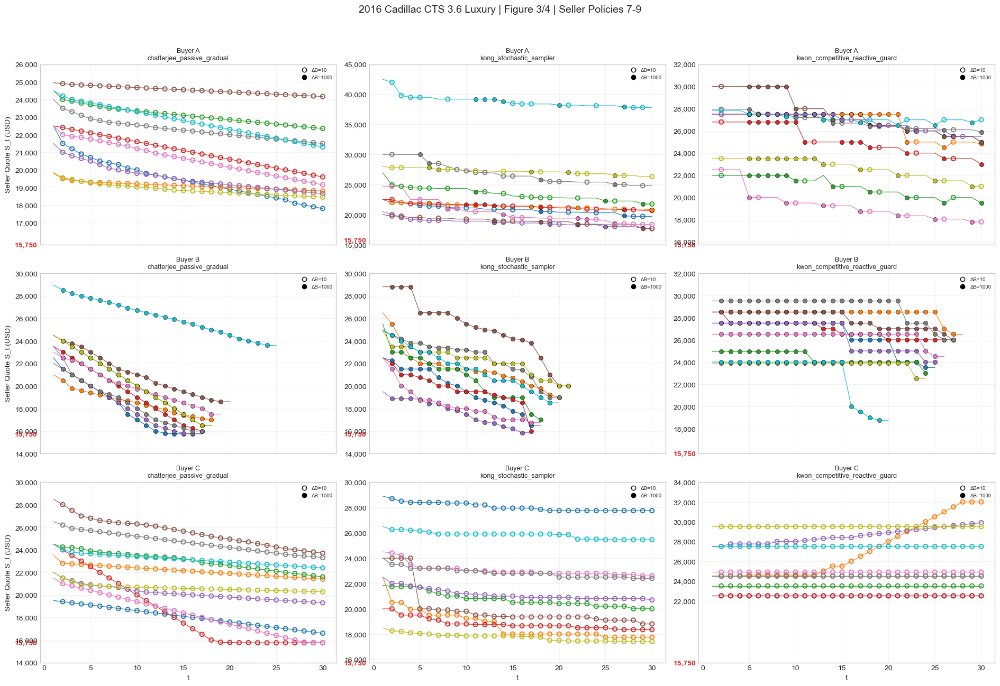

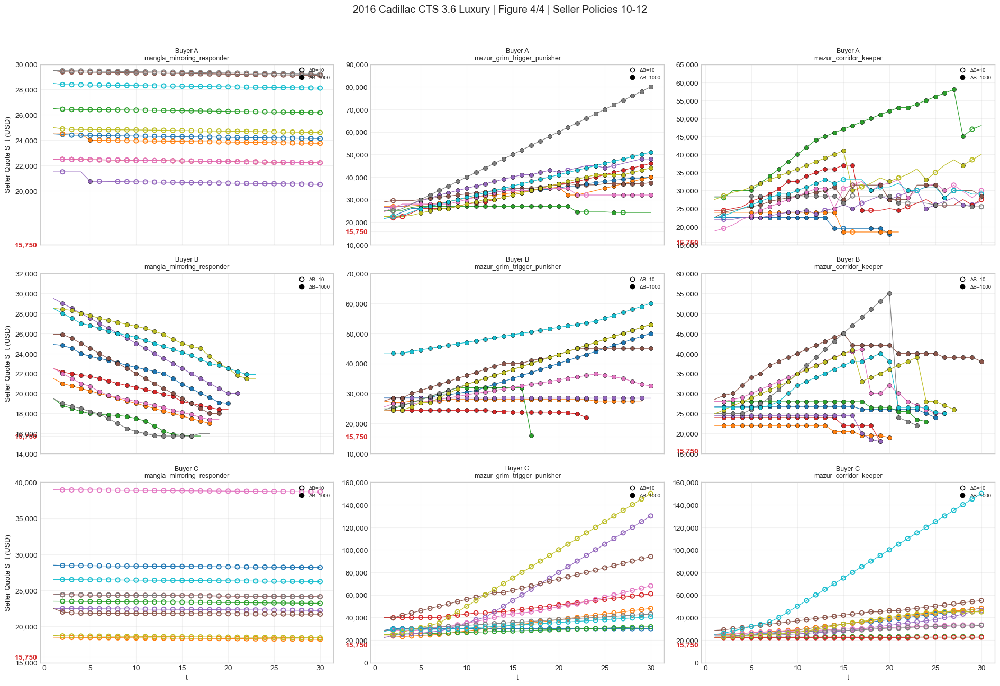

## Product: 2019 Honda Accord Sport 1.5T

/var/folders/nh/9wk739l10nq71s_zxqsp02zc0000gn/T/ipykernel_54264/2304958022.py:96: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(y_labels)
/var/folders/nh/9wk739l10nq71s_zxqsp02zc0000gn/T/ipykernel_54264/2304958022.py:96: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(y_labels)
/var/folders/nh/9wk739l10nq71s_zxqsp02zc0000gn/T/ipykernel_54264/2304958022.py:96: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(y_labels)
/var/folders/nh/9wk739l10nq71s_zxqsp02zc0000gn/T/ipykernel_54264/2304958022.py:96: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(y_labels)
/var/folders/nh/9wk739l10nq71s_zxqsp02zc0000gn/T/ipykernel_54264/2304958022.py:96: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(y_labels)
/var/folders/nh/9wk739l10nq71s_zxqsp02zc0000gn/T/ipyker

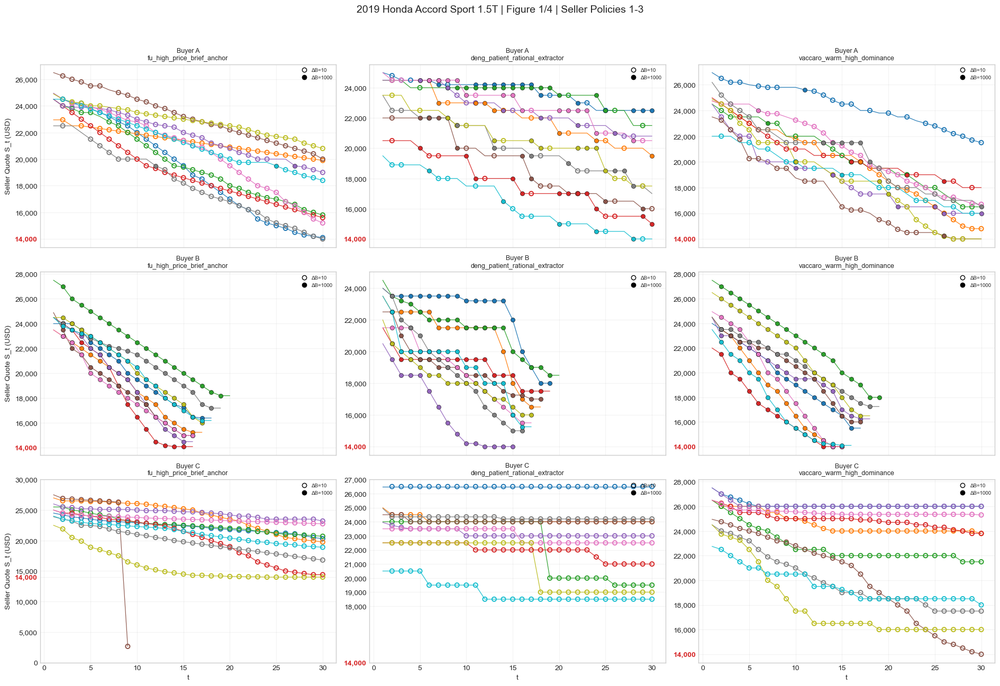

/var/folders/nh/9wk739l10nq71s_zxqsp02zc0000gn/T/ipykernel_54264/2304958022.py:96: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(y_labels)
/var/folders/nh/9wk739l10nq71s_zxqsp02zc0000gn/T/ipykernel_54264/2304958022.py:96: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(y_labels)
/var/folders/nh/9wk739l10nq71s_zxqsp02zc0000gn/T/ipykernel_54264/2304958022.py:96: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(y_labels)
/var/folders/nh/9wk739l10nq71s_zxqsp02zc0000gn/T/ipykernel_54264/2304958022.py:96: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(y_labels)
/var/folders/nh/9wk739l10nq71s_zxqsp02zc0000gn/T/ipykernel_54264/2304958022.py:96: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(y_labels)


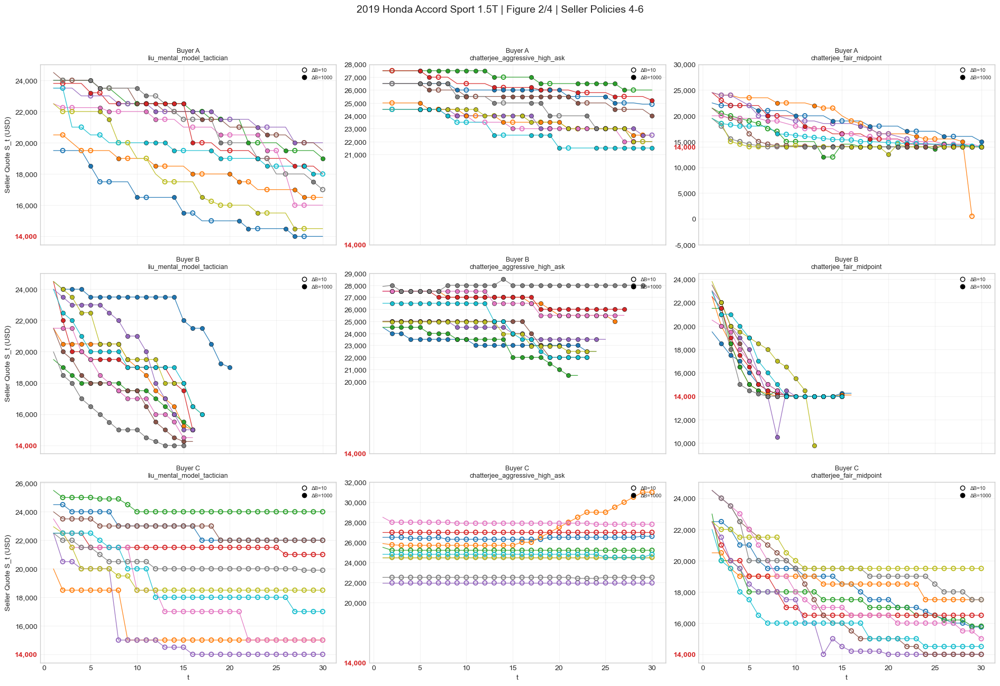

/var/folders/nh/9wk739l10nq71s_zxqsp02zc0000gn/T/ipykernel_54264/2304958022.py:96: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(y_labels)
/var/folders/nh/9wk739l10nq71s_zxqsp02zc0000gn/T/ipykernel_54264/2304958022.py:96: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(y_labels)
/var/folders/nh/9wk739l10nq71s_zxqsp02zc0000gn/T/ipykernel_54264/2304958022.py:96: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(y_labels)


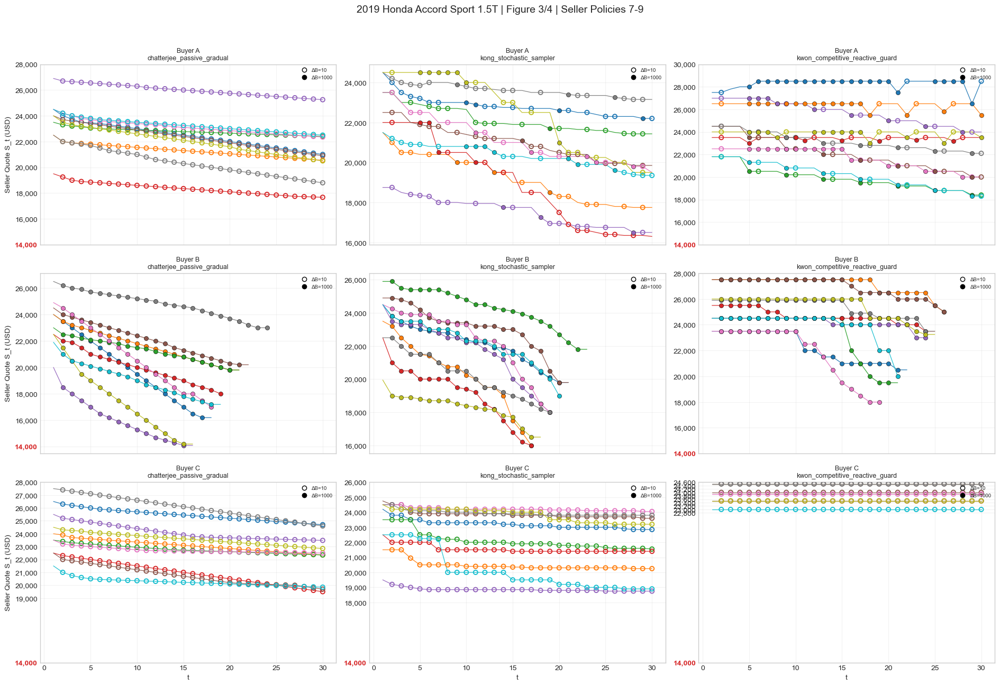

/var/folders/nh/9wk739l10nq71s_zxqsp02zc0000gn/T/ipykernel_54264/2304958022.py:96: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(y_labels)


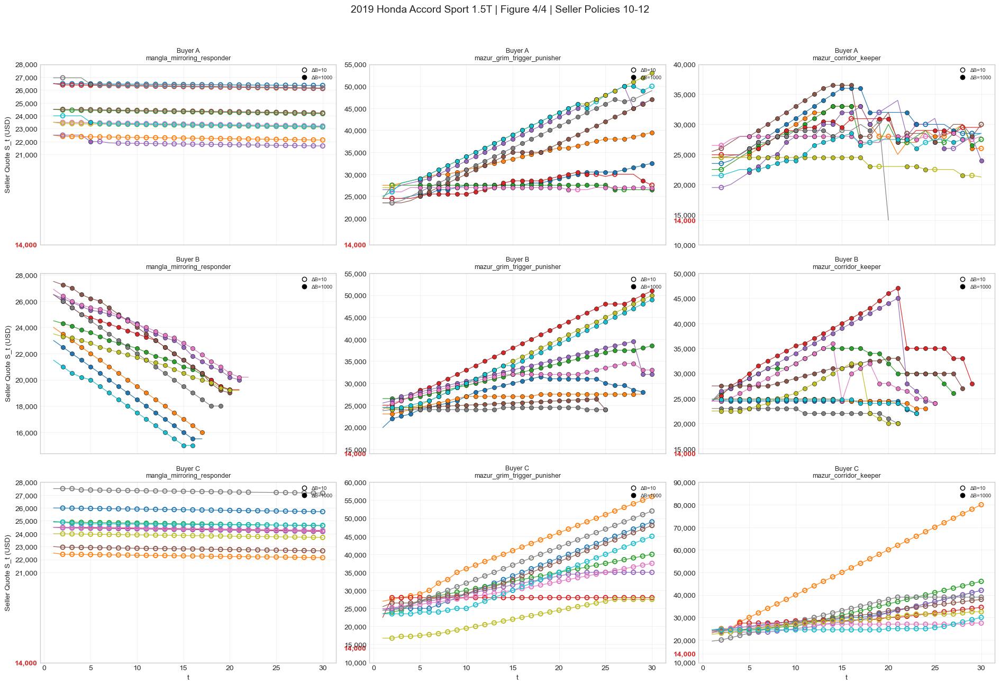

## Product: 2022 Toyota RAV4 XLE AWD

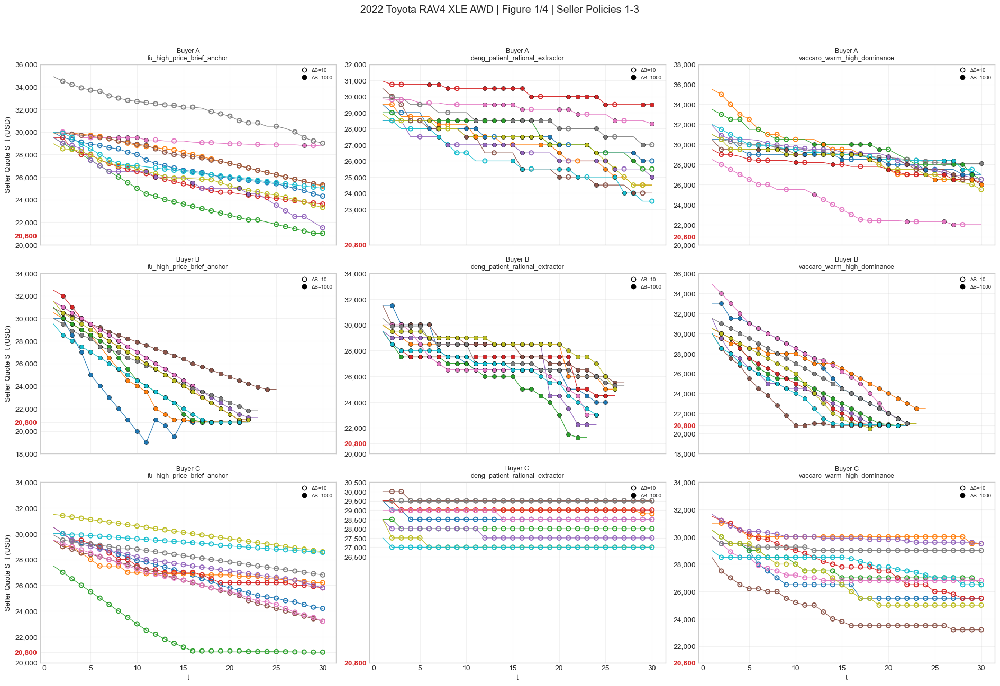

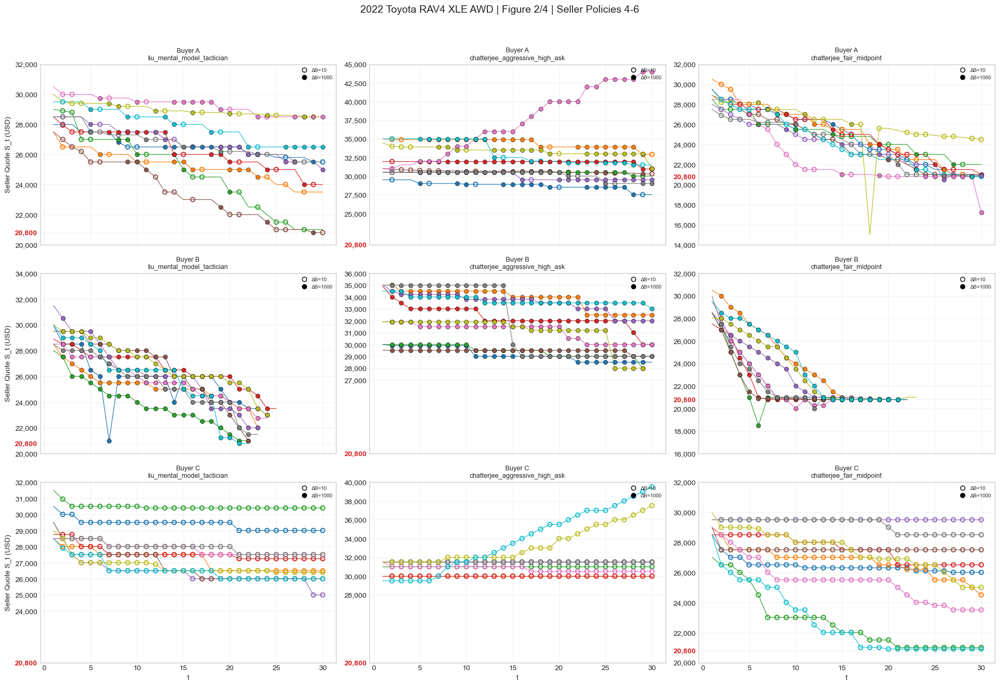

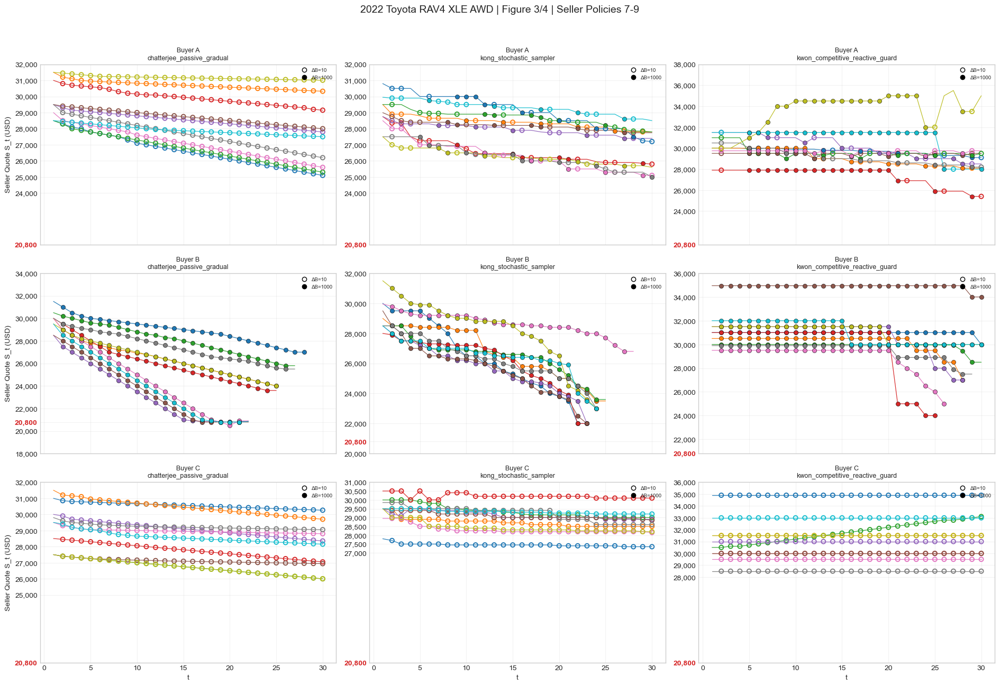

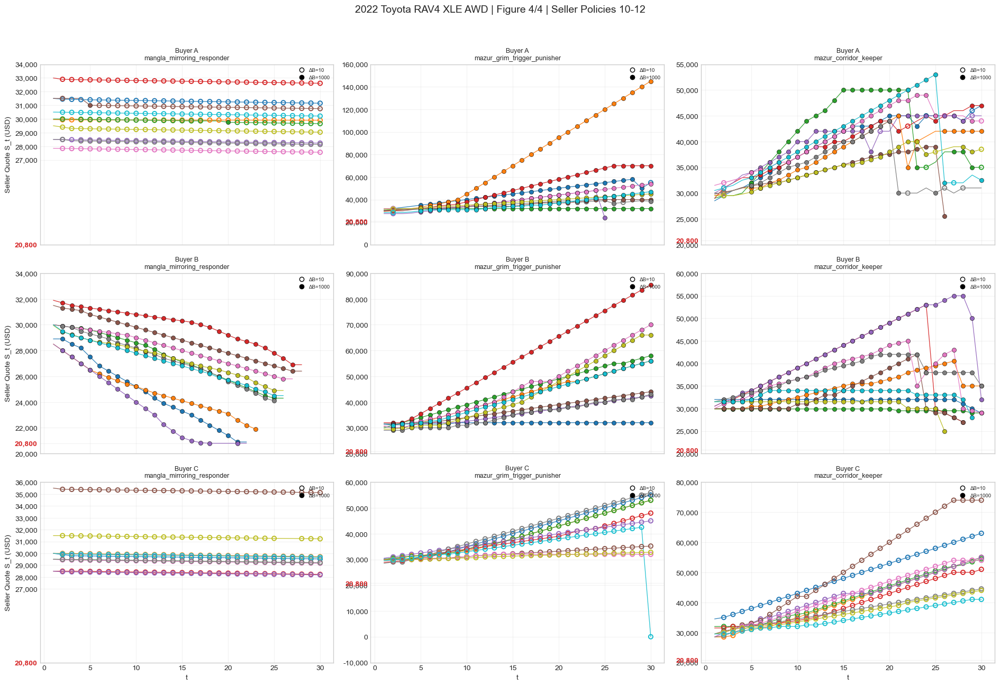

## Product: 2023 Ford Mustang GT Premium

/var/folders/nh/9wk739l10nq71s_zxqsp02zc0000gn/T/ipykernel_54264/2304958022.py:96: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(y_labels)
/var/folders/nh/9wk739l10nq71s_zxqsp02zc0000gn/T/ipykernel_54264/2304958022.py:96: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(y_labels)
/var/folders/nh/9wk739l10nq71s_zxqsp02zc0000gn/T/ipykernel_54264/2304958022.py:96: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(y_labels)
/var/folders/nh/9wk739l10nq71s_zxqsp02zc0000gn/T/ipykernel_54264/2304958022.py:96: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(y_labels)
/var/folders/nh/9wk739l10nq71s_zxqsp02zc0000gn/T/ipykernel_54264/2304958022.py:96: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(y_labels)
/var/folders/nh/9wk739l10nq71s_zxqsp02zc0000gn/T/ipyker

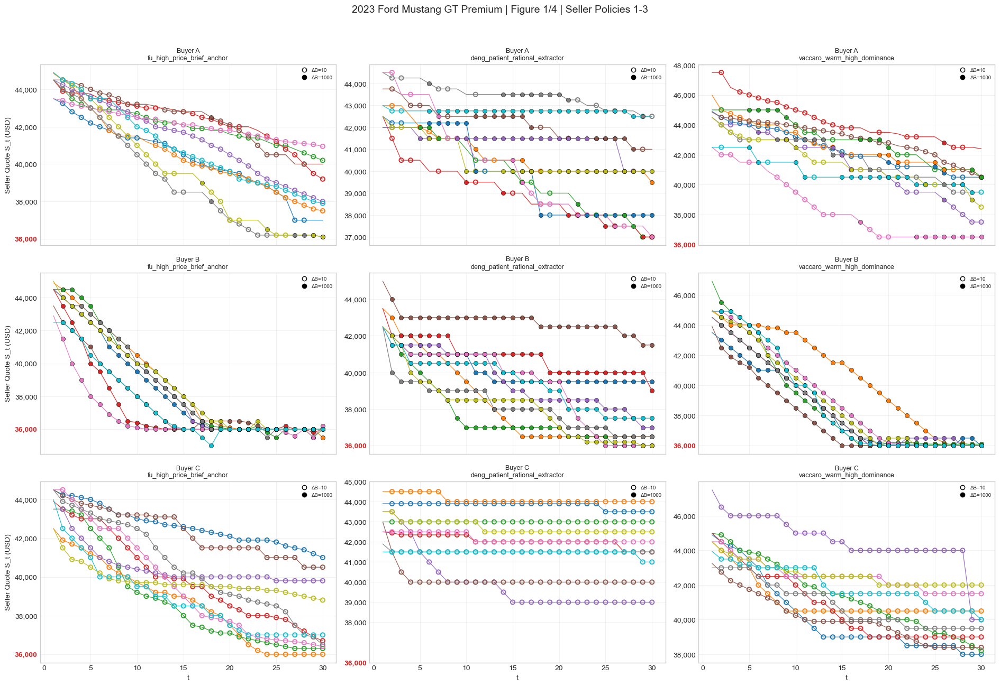

/var/folders/nh/9wk739l10nq71s_zxqsp02zc0000gn/T/ipykernel_54264/2304958022.py:96: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(y_labels)
/var/folders/nh/9wk739l10nq71s_zxqsp02zc0000gn/T/ipykernel_54264/2304958022.py:96: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(y_labels)
/var/folders/nh/9wk739l10nq71s_zxqsp02zc0000gn/T/ipykernel_54264/2304958022.py:96: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(y_labels)
/var/folders/nh/9wk739l10nq71s_zxqsp02zc0000gn/T/ipykernel_54264/2304958022.py:96: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(y_labels)
/var/folders/nh/9wk739l10nq71s_zxqsp02zc0000gn/T/ipykernel_54264/2304958022.py:96: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(y_labels)


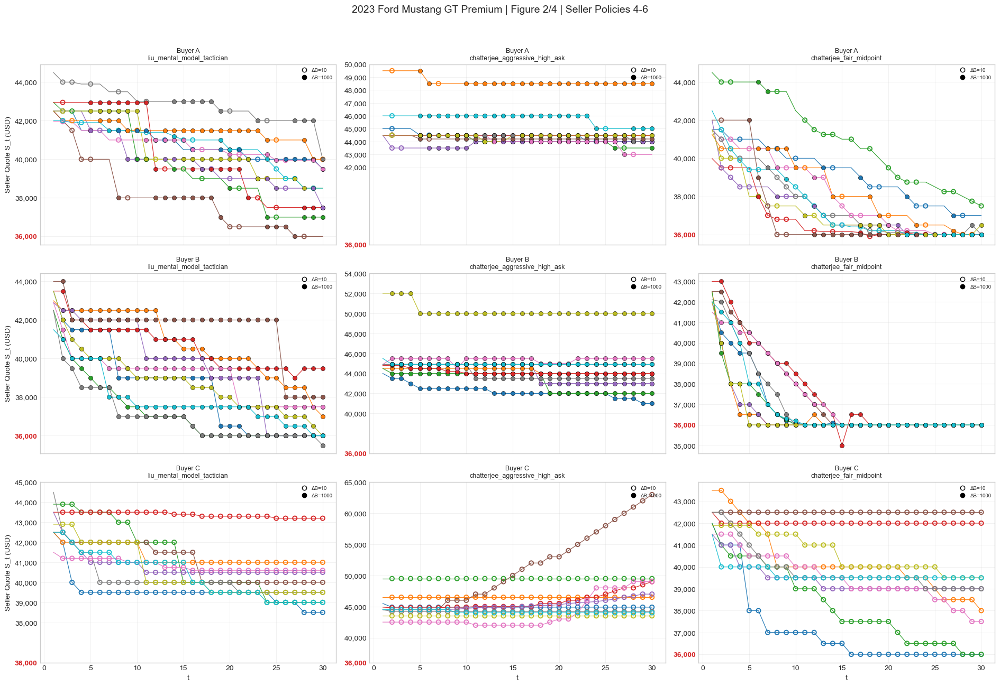

/var/folders/nh/9wk739l10nq71s_zxqsp02zc0000gn/T/ipykernel_54264/2304958022.py:96: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(y_labels)
/var/folders/nh/9wk739l10nq71s_zxqsp02zc0000gn/T/ipykernel_54264/2304958022.py:96: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(y_labels)


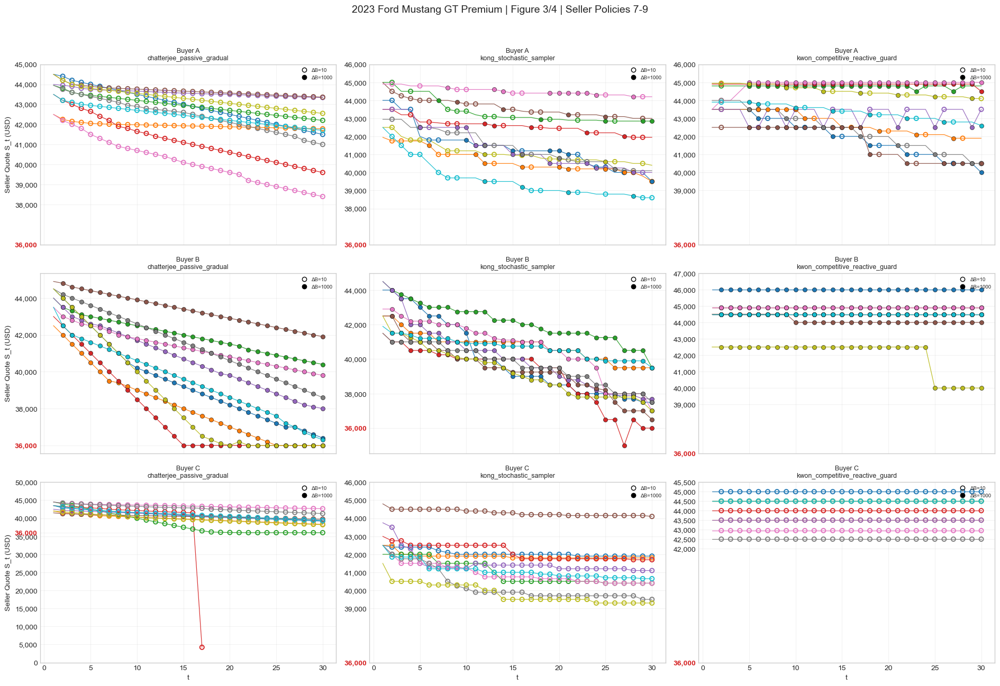

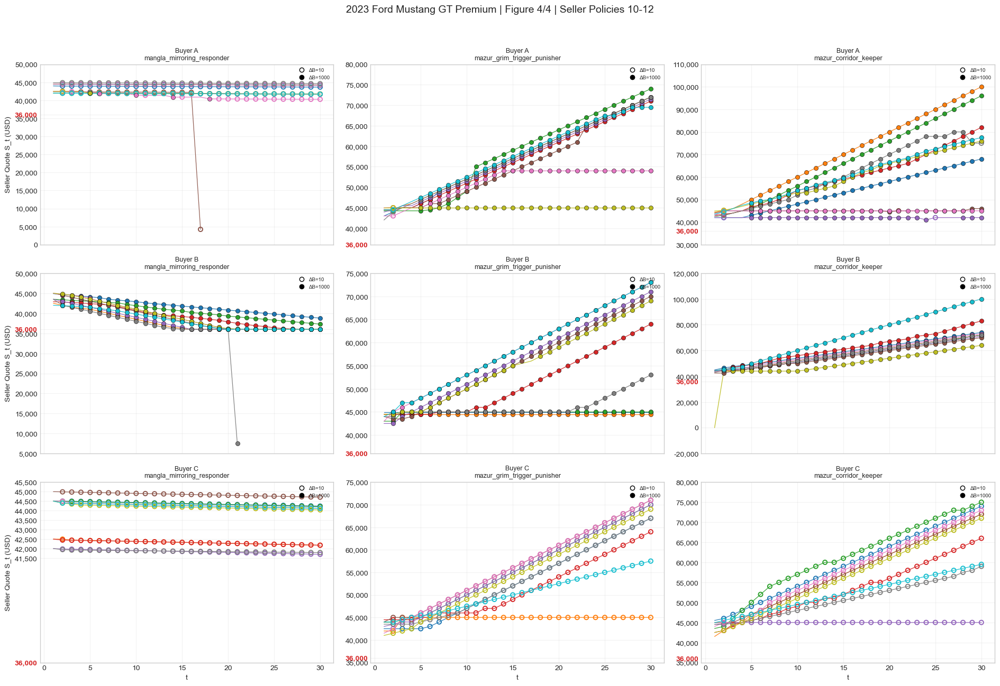

In [24]:
policy_order = [
    'fu_high_price_brief_anchor',
    'deng_patient_rational_extractor',
    'vaccaro_warm_high_dominance',
    'liu_mental_model_tactician',
    'chatterjee_aggressive_high_ask',
    'chatterjee_fair_midpoint',
    'chatterjee_passive_gradual',
    'kong_stochastic_sampler',
    'kwon_competitive_reactive_guard',
    'mangla_mirroring_responder',
    'mazur_grim_trigger_punisher',
    'mazur_corridor_keeper',
]
policy_order = [p for p in policy_order if p in set(df["policy"])]
policy_chunks = [policy_order[i:i+3] for i in range(0, len(policy_order), 3)]

car_pref = [
    '2014 Mercedes-Benz S550',
    '2016 Cadillac CTS 3.6 Luxury',
    '2019 Honda Accord Sport 1.5T',
    '2022 Toyota RAV4 XLE AWD',
    '2023 Ford Mustang GT Premium',
]
cars_seen = sorted(set(df["car"].dropna().tolist()))
car_order = [c for c in car_pref if c in cars_seen] + [c for c in cars_seen if c not in set(car_pref)]

def color_map_for_sims(sim_ids):
    sim_ids = sorted(sim_ids)
    n = len(sim_ids)
    base = plt.get_cmap('tab10')
    return {sid: base(i % 10) for i, sid in enumerate(sim_ids)}

marker_handles = [
    Line2D([0],[0], marker='o', linestyle='None', markerfacecolor='none', markeredgecolor='black', markersize=6, label='ΔB=10'),
    Line2D([0],[0], marker='o', linestyle='None', markerfacecolor='black', markeredgecolor='black', markersize=6, label='ΔB=1000'),
]

for car in car_order:
    display(Markdown(f'## Product: {car}'))
    car_df = df[df["car"] == car]
    car_mark = df_mark[df_mark["car"] == car]

    for fig_idx, chunk in enumerate(policy_chunks, start=1):
        fig, axes = plt.subplots(3, 3, figsize=(19, 13), sharex=True, sharey=False)

        for r, buyer in enumerate(['A', 'B', 'C']):
            for c, policy in enumerate(chunk):
                ax = axes[r, c]
                sub_line = car_df[(car_df["buyer_scheme"] == buyer) & (car_df["policy"] == policy)]
                sub_mark = car_mark[(car_mark["buyer_scheme"] == buyer) & (car_mark["policy"] == policy)]

                if sub_line.empty:
                    ax.set_title(f'Buyer {buyer}\n{policy} (no data)', fontsize=9)
                    ax.grid(True, alpha=0.25)
                    continue

                sim_ids = sorted(sub_line["sim_id"].unique().tolist())
                sim_colors = color_map_for_sims(sim_ids)

                # one color per simulation trajectory
                for sid, g in sub_line.groupby('sim_id', sort=True):
                    g = g.sort_values("t")
                    ax.plot(g["t"], g["S_t"], color=sim_colors[sid], alpha=0.95, linewidth=0.9)

                # marker style: hollow for dB=10, filled for dB=1000
                pts10 = sub_mark[sub_mark['is_db_10']]
                pts1000 = sub_mark[sub_mark['is_db_1000']]

                for sid, g in pts10.groupby('sim_id', sort=True):
                    color = sim_colors.get(sid, "black")
                    ax.scatter(g["t"], g["S_t"], s=34, facecolors="none", edgecolors=color, linewidths=1.4, zorder=4)

                for sid, g in pts1000.groupby('sim_id', sort=True):
                    color = sim_colors.get(sid, "black")
                    ax.scatter(g["t"], g["S_t"], s=34, facecolors=color, edgecolors="black", linewidths=0.4, zorder=5)

                ax.set_title(f'Buyer {buyer}\n{policy}', fontsize=9)
                ax.grid(True, alpha=0.25)

                # Mark dealer cost v on the y-axis tick labels (bold), no extra line in panel.
                v_vals = sub_line["v"].dropna()
                if not v_vals.empty:
                    v_val = float(v_vals.iloc[0])
                    y_ticks = list(ax.get_yticks())
                    tol_tick = max(1e-6, 1e-6 * max(abs(v_val), 1.0))
                    if not any(abs(t - v_val) <= tol_tick for t in y_ticks):
                        y_ticks = sorted(y_ticks + [v_val])
                        ax.set_yticks(y_ticks)

                    y_ticks_final = ax.get_yticks()
                    tol_label = max(1e-6, 1e-4 * max(abs(v_val), 1.0))
                    y_labels = []
                    for t in y_ticks_final:
                        y_labels.append(f"{t:,.0f}")
                    ax.set_yticklabels(y_labels)

                    for lbl, t in zip(ax.get_yticklabels(), y_ticks_final):
                        if abs(t - v_val) <= tol_label:
                            lbl.set_color("#d62728")
                            lbl.set_fontweight("bold")

                ax.legend(handles=marker_handles, loc="upper right", fontsize=7, framealpha=0.85, borderpad=0.25, handletextpad=0.35)

        for rr in range(3):
            axes[rr, 0].set_ylabel('Seller Quote S_t (USD)')
        for cc in range(3):
            axes[2, cc].set_xlabel('t')

        lo = 3 * (fig_idx - 1) + 1
        hi = 3 * (fig_idx - 1) + len(chunk)
        fig.suptitle(f'{car} | Figure {fig_idx}/4 | Seller Policies {lo}-{hi}', fontsize=14, y=0.995)
        plt.tight_layout(rect=[0, 0, 1, 0.97])
        plt.show()
